
# Airbnb Price Prediction using Multiple Linear Regression (MLR)




In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [29]:

df = pd.read_csv("AB_NYC_2019.csv")

df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [30]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [31]:
df = df.copy()

# Fill reviews_per_month with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Drop last_review column
df = df.drop('last_review', axis=1)

# Drop very few missing rows for 'name' and 'host_name'
df = df.dropna(subset=['name', 'host_name'])

# Remove extreme price outliers
df = df[df['price'] < 500]

# Select the desired columns for the model
df = df[[
    'neighbourhood_group',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'price'
]]

df.head()

,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month,availability_365,price
0,Brooklyn,Private room,1,9,0.21,365,149
1,Manhattan,Entire home/apt,1,45,0.38,355,225
2,Manhattan,Private room,3,0,0.00,365,150
3,Brooklyn,Entire home/apt,1,270,4.64,194,89
4,Manhattan,Entire home/apt,10,9,0.10,0,80


###Exploratory Data Analysis





In [32]:

print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nPrice Statistics")
print(df['price'].describe())


Dataset Shape: (47623, 7)

Missing Values
neighbourhood_group    0
room_type              0
minimum_nights         0
number_of_reviews      0
reviews_per_month      0
availability_365       0
price                  0
dtype: int64

Price Statistics
count    47623.000000
mean       130.056422
std         85.086962
min          0.000000
25%         68.000000
50%        100.000000
75%        170.000000
max        499.000000
Name: price, dtype: float64


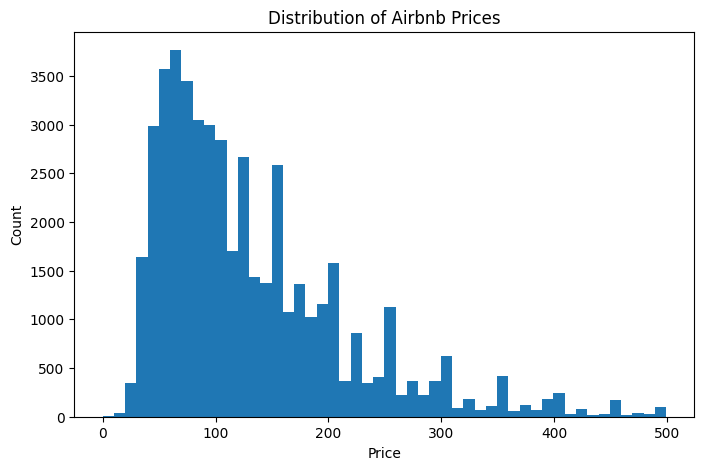

In [33]:

# Price distribution

plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=50)

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("Distribution of Airbnb Prices")

plt.show()


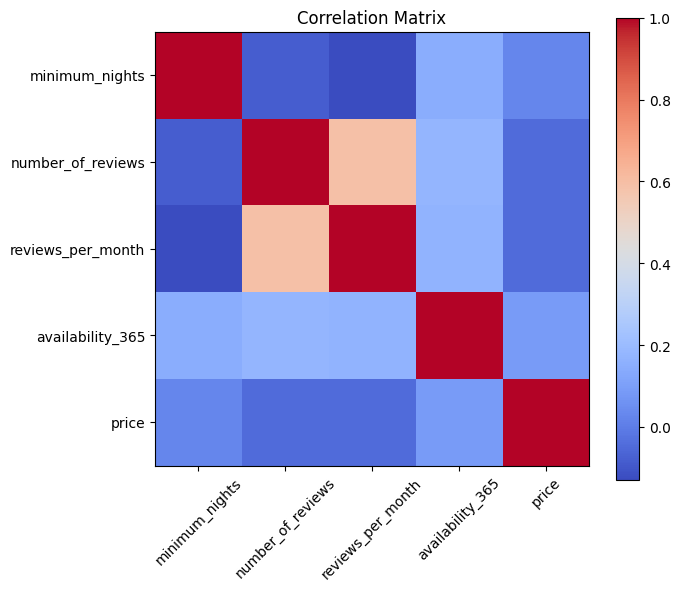

In [34]:

# Correlation matrix

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()


## Feature Encoding

In [35]:

encoder = LabelEncoder()

df['room_type'] = encoder.fit_transform(df['room_type'])

df['neighbourhood_group'] = encoder.fit_transform(df['neighbourhood_group'])

df.head()


,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month,availability_365,price
0,1,1,1,9,0.21,365,149
1,2,0,1,45,0.38,355,225
2,2,1,3,0,0.00,365,150
3,1,0,1,270,4.64,194,89
4,2,0,10,9,0.10,0,80


##  Features and Target

In [36]:
X = df.drop('price', axis=1)

# Log transformation improves regression performance
# Adding a small constant (1e-6) to handle zero values in 'price' before log transformation
y = np.log(df['price'] + 1e-6)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (47623, 6)
Target Shape: (47623,)


## Train Test Split

In [37]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (38098, 6)
Testing Data: (9525, 6)


##Feature Scaling

In [38]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


##  Multiple Linear Regression Model

In [39]:

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [40]:

# Model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients


,Feature,Coefficient
0,neighbourhood_group,0.042460
1,room_type,-0.412723
2,minimum_nights,-0.027772
3,number_of_reviews,-0.012639
4,reviews_per_month,-0.026826
5,availability_365,0.064760


## Predictions

In [41]:

y_pred = model.predict(X_test)

# Convert log values back to normal prices
actual_prices = np.exp(y_test)
predicted_prices = np.exp(y_pred)

results = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

results.head(10)


,Actual Price,Predicted Price
0,375.000001,175.114973
1,200.000001,159.322650
2,400.000001,165.861100
3,43.000001,68.054945
4,60.000001,68.448101
5,66.000001,86.555232
6,129.000001,168.610944
7,250.000001,148.317817
8,200.000001,157.066977
9,150.000001,76.791232



## Model Evaluation

In [49]:

mae = mean_absolute_error(actual_prices, predicted_prices)

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

r2 = r2_score(actual_prices, predicted_prices)

print("Mean Absolute Error (MAE):", round(mae, 2))

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

print("R2 Score:", round(r2, 4))


Mean Absolute Error (MAE): 43.21
Root Mean Squared Error (RMSE): 65.06
R2 Score: 0.398


##Actual vs Predicted Graph

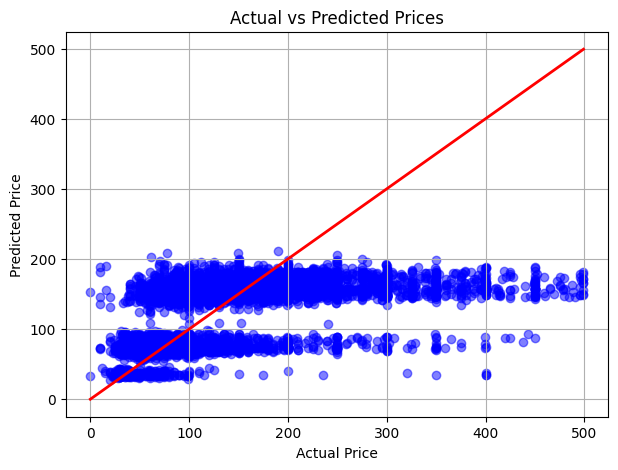

In [43]:

plt.figure(figsize=(7,5))

plt.scatter(
    actual_prices,
    predicted_prices,
    color='blue',
    alpha=0.5
)

plt.plot(
    [actual_prices.min(), actual_prices.max()],
    [actual_prices.min(), actual_prices.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.grid(True)

plt.show()


##  Residual Analysis

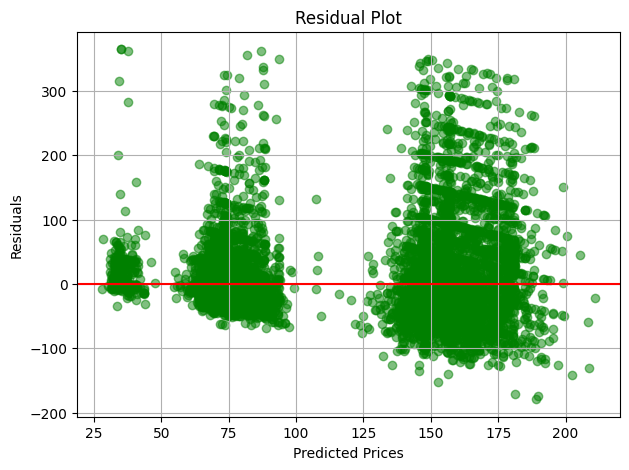

In [44]:

residuals = actual_prices - predicted_prices

plt.figure(figsize=(7,5))

plt.scatter(
    predicted_prices,
    residuals,
    color='green',
    alpha=0.5
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


## Feature Importance

In [45]:


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance


,Feature,Importance
5,availability_365,0.064760
0,neighbourhood_group,0.042460
3,number_of_reviews,-0.012639
4,reviews_per_month,-0.026826
2,minimum_nights,-0.027772
1,room_type,-0.412723


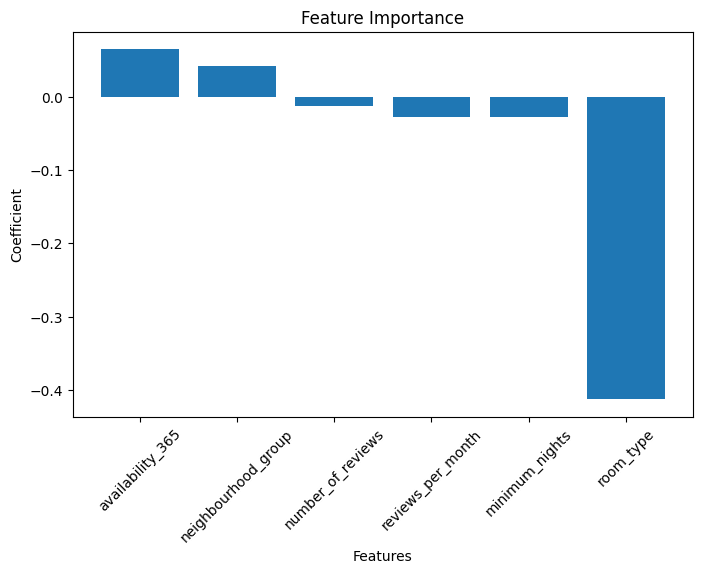

In [46]:

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.title("Feature Importance")

plt.show()



# Conclusion

- Multiple Linear Regression was successfully implemented.
- EDA and preprocessing improved the model.
- Log transformation reduced prediction errors.
- The model predicts Airbnb prices using multiple features.
- Residual analysis and feature importance were studied.


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [48]:
r2 = r2_score(y_test, rf_pred)

print(r2)

actual_prices = np.exp(y_test)
predicted_prices = np.exp(rf_pred)

results = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

results

0.41972465995647024


,Actual Price,Predicted Price
0,375.000001,218.331244
1,200.000001,176.354476
2,400.000001,159.129713
3,43.000001,79.058603
4,60.000001,50.288956
...,...,...
9520,45.000001,54.007471
9521,65.000001,98.335341
9522,170.000001,143.383690
9523,125.000001,173.796694
